In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Affichage
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

df.head(10)

,customer_id,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,CUST_00000,58,Male,Unemployed,58137.751192,115,524.679407,1,171.342369,49,768.877511,9,16,1,539,5,14435.423445,2,0,0,15510.576882,1
1,CUST_00001,48,Male,Self-Employed,26174.922827,32,2635.203357,1,985.607164,1,580.287785,9,1,2,494,5,11263.099341,2,0,0,14819.436498,1
2,CUST_00002,34,Other,Unemployed,75566.837265,14,2334.341061,9,994.310119,42,564.013508,36,5,6,437,3,15017.144132,5,0,0,10909.806507,1
3,CUST_00003,62,Male,Self-Employed,35197.961516,179,2425.384332,10,366.115346,4,838.489200,31,7,7,809,1,12626.138476,2,0,0,500.000000,0
4,CUST_00004,27,Female,Self-Employed,12136.998349,225,10.000000,8,786.752258,16,462.495522,35,16,3,522,1,13576.704320,4,0,0,9514.591618,1
5,CUST_00005,40,Male,Employed,76906.812198,84,1260.654535,2,227.110255,36,0.000000,63,5,7,727,4,1267.328320,2,0,0,5424.024525,0
6,CUST_00006,58,Female,Employed,14485.730000,48,1437.594031,3,20.000000,34,633.589112,14,11,0,754,1,13356.388072,2,1,0,9004.582223,1
7,CUST_00007,38,Female,Employed,67355.217921,173,1959.997183,0,426.243321,7,788.186496,72,15,2,307,5,18254.853569,5,0,0,12632.805584,1
8,CUST_00008,42,Female,Employed,62980.151376,132,2220.699649,0,584.181270,42,618.813748,15,5,3,515,3,8376.686391,7,0,0,9538.756785,1
9,CUST_00009,30,Female,Self-Employed,55751.973822,99,2527.700512,3,1025.489663,2,180.263305,45,1,4,583,1,17976.626918,6,0,0,2896.670257,1


1 : Supprimer

In [3]:
df.drop("customer_id", axis=1, inplace=True)

2.Encodage  
================================================

In [4]:
df_encoded = df.copy()

# ============================================================
# 1. STANDARDISER / NETTOYER GENDER (si nécessaire)
# ============================================================

# Cas 1 : gender est déjà en texte (male/female/other)
if df_encoded['gender'].dtype == 'object':
    df_encoded['gender'] = df_encoded['gender'].str.lower()

# Cas 2 : gender est encodé en 0/1/2
else:
    df_encoded['gender'] = df_encoded['gender'].map({
        0: 'male',
        1: 'female',
        2: 'other'
    })

# ============================================================
# 2. STANDARDISER EMPLOYMENT STATUS
# ============================================================

df_encoded['employment_status'] = df_encoded['employment_status'].str.strip()

# ============================================================
# 3. ONE-HOT ENCODING (résultat propre en 0/1)
# ============================================================

df_encoded = pd.get_dummies(
    df_encoded,
    columns=['gender', 'employment_status'],
    dtype=int
)

# ============================================================
# 4. AFFICHAGE FINAL DES COLONNES CIBLES
# ============================================================

print(df_encoded.filter(like='gender').columns)
print(df_encoded.filter(like='employment_status').columns)

Index(['gender_female', 'gender_male', 'gender_other'], dtype='object')
Index(['employment_status_Employed', 'employment_status_Self-Employed',
       'employment_status_Unemployed'],
      dtype='object')


In [5]:
df_encoded.head(10)

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk,gender_female,gender_male,gender_other,employment_status_Employed,employment_status_Self-Employed,employment_status_Unemployed
0,58,58137.751192,115,524.679407,1,171.342369,49,768.877511,9,16,1,539,5,14435.423445,2,0,0,15510.576882,1,0,1,0,0,0,1
1,48,26174.922827,32,2635.203357,1,985.607164,1,580.287785,9,1,2,494,5,11263.099341,2,0,0,14819.436498,1,0,1,0,0,1,0
2,34,75566.837265,14,2334.341061,9,994.310119,42,564.013508,36,5,6,437,3,15017.144132,5,0,0,10909.806507,1,0,0,1,0,0,1
3,62,35197.961516,179,2425.384332,10,366.115346,4,838.489200,31,7,7,809,1,12626.138476,2,0,0,500.000000,0,0,1,0,0,1,0
4,27,12136.998349,225,10.000000,8,786.752258,16,462.495522,35,16,3,522,1,13576.704320,4,0,0,9514.591618,1,1,0,0,0,1,0
5,40,76906.812198,84,1260.654535,2,227.110255,36,0.000000,63,5,7,727,4,1267.328320,2,0,0,5424.024525,0,0,1,0,1,0,0
6,58,14485.730000,48,1437.594031,3,20.000000,34,633.589112,14,11,0,754,1,13356.388072,2,1,0,9004.582223,1,1,0,0,1,0,0
7,38,67355.217921,173,1959.997183,0,426.243321,7,788.186496,72,15,2,307,5,18254.853569,5,0,0,12632.805584,1,1,0,0,1,0,0
8,42,62980.151376,132,2220.699649,0,584.181270,42,618.813748,15,5,3,515,3,8376.686391,7,0,0,9538.756785,1,1,0,0,1,0,0
9,30,55751.973822,99,2527.700512,3,1025.489663,2,180.263305,45,1,4,583,1,17976.626918,6,0,0,2896.670257,1,1,0,0,0,1,0


2 : Traitement des valeurs aberrantes

À partir des boîtes à moustaches, nous avons identifié des valeurs aberrantes dans certaines variables numériques, notamment : `avg_monthly_balance`, `avg_deposit_amount` et `debit_card_spending`.

Afin de limiter leur influence sur le modèle de Machine Learning, nous avons appliqué la méthode IQR. Les valeurs situées en dehors des bornes ont été remplacées par la moyenne de la variable concernée.

In [6]:
import numpy as np

cols_outliers = [
    'avg_monthly_balance',
    'avg_deposit_amount',
    'debit_card_spending'
    
]

for col in cols_outliers:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mean_value = df_encoded[col].mean()

    df_encoded[col] = np.where(
        (df_encoded[col] < lower_bound) | (df_encoded[col] > upper_bound),
        mean_value,
        df_encoded[col]
    )

    print(f"{col} : outliers remplacés par la moyenne")

avg_monthly_balance : outliers remplacés par la moyenne
avg_deposit_amount : outliers remplacés par la moyenne
debit_card_spending : outliers remplacés par la moyenne


Vérification cellule

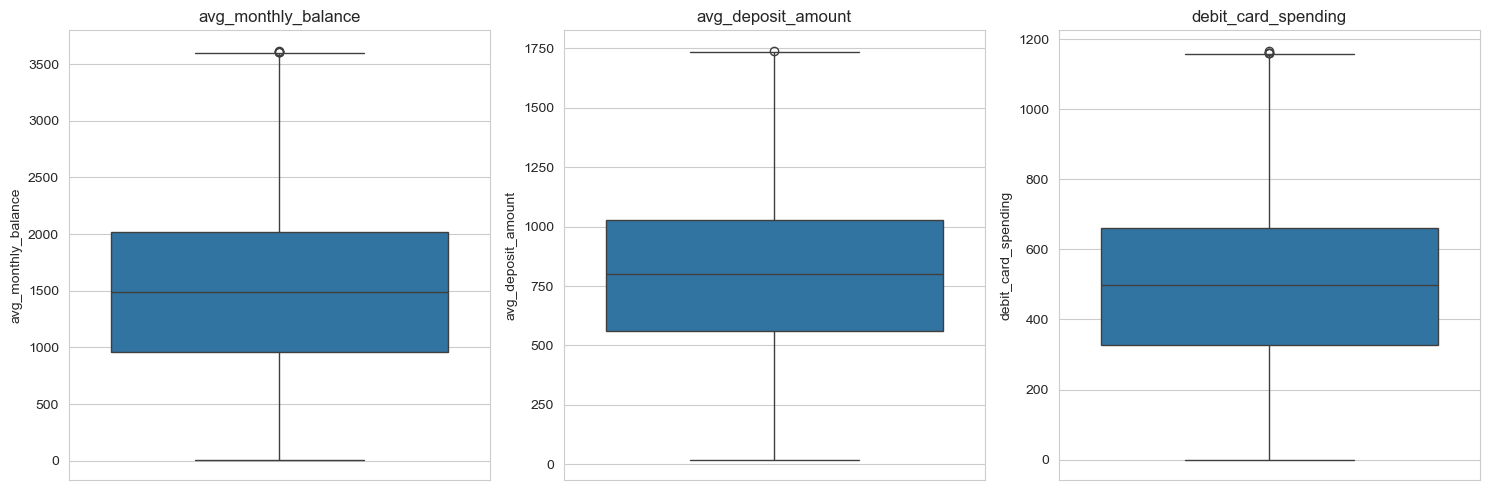

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cols_outliers):
    sns.boxplot(y=df_encoded[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

3.Feature Engineering
======================

1. Debt to Income Ratio

In [11]:
df_encoded['debt_to_income_ratio'] = (
    df_encoded['total_outstanding_debt']
    / df_encoded['annual_income']
)

2. Loan to Income Ratio

In [12]:
df_encoded['loan_to_income_ratio'] = (
    df_encoded['loan_application_amount']
    / df_encoded['annual_income']
)

3. Spending Ratio

In [13]:
df_encoded['spending_ratio'] = (
    df_encoded['debit_card_spending']
    / df_encoded['annual_income']
)

4. Balance to Debt Ratio

In [23]:
df_encoded['balance_to_debt_ratio'] = (
    df_encoded['avg_monthly_balance']
    / (df_encoded['total_outstanding_debt'] + 1)
)

In [24]:
df_encoded.columns

Index(['age', 'annual_income', 'account_age_months', 'avg_monthly_balance',
       'num_deposits_per_month', 'avg_deposit_amount',
       'debit_card_usage_frequency', 'debit_card_spending',
       'mobile_banking_logins', 'online_transfer_frequency',
       'atm_withdrawal_frequency', 'credit_score', 'num_open_loans',
       'total_outstanding_debt', 'late_payment_count', 'loan_default_history',
       'fraud_flag', 'loan_application_amount', 'credit_risk', 'gender_female',
       'gender_male', 'gender_other', 'employment_status_Employed',
       'employment_status_Self-Employed', 'employment_status_Unemployed',
       'debt_to_income_ratio', 'loan_to_income_ratio', 'spending_ratio',
       'balance_to_debt_ratio'],
      dtype='object')

In [25]:
df_encoded.head(10)

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk,gender_female,gender_male,gender_other,employment_status_Employed,employment_status_Self-Employed,employment_status_Unemployed,debt_to_income_ratio,loan_to_income_ratio,spending_ratio,balance_to_debt_ratio
0,58,58137.751192,115,524.679407,1,171.342369,49,768.877511,9,16,1,539,5,14435.423445,2,0,0,15510.576882,1,0,1,0,0,0,1,0.248297,0.266790,0.013225,0.036344
1,48,26174.922827,32,2635.203357,1,985.607164,1,580.287785,9,1,2,494,5,11263.099341,2,0,0,14819.436498,1,0,1,0,0,1,0,0.430301,0.566169,0.022170,0.233947
2,34,75566.837265,14,2334.341061,9,994.310119,42,564.013508,36,5,6,437,3,15017.144132,5,0,0,10909.806507,1,0,0,1,0,0,1,0.198727,0.144373,0.007464,0.155435
3,62,35197.961516,179,2425.384332,10,366.115346,4,838.489200,31,7,7,809,1,12626.138476,2,0,0,500.000000,0,0,1,0,0,1,0,0.358718,0.014205,0.023822,0.192077
4,27,12136.998349,225,10.000000,8,786.752258,16,462.495522,35,16,3,522,1,13576.704320,4,0,0,9514.591618,1,1,0,0,0,1,0,1.118621,0.783933,0.038106,0.000737
5,40,76906.812198,84,1260.654535,2,227.110255,36,0.000000,63,5,7,727,4,1267.328320,2,0,0,5424.024525,0,0,1,0,1,0,0,0.016479,0.070527,0.000000,0.993950
6,58,14485.730000,48,1437.594031,3,20.000000,34,633.589112,14,11,0,754,1,13356.388072,2,1,0,9004.582223,1,1,0,0,1,0,0,0.922038,0.621617,0.043739,0.107625
7,38,67355.217921,173,1959.997183,0,426.243321,7,788.186496,72,15,2,307,5,18254.853569,5,0,0,12632.805584,1,1,0,0,1,0,0,0.271024,0.187555,0.011702,0.107363
8,42,62980.151376,132,2220.699649,0,584.181270,42,618.813748,15,5,3,515,3,8376.686391,7,0,0,9538.756785,1,1,0,0,1,0,0,0.133005,0.151457,0.009826,0.265073
9,30,55751.973822,99,2527.700512,3,1025.489663,2,180.263305,45,1,4,583,1,17976.626918,6,0,0,2896.670257,1,1,0,0,0,1,0,0.322439,0.051956,0.003233,0.140603


In [26]:
df_encoded.to_csv(
    "credit_risk_dataset_clean.csv",
    index=False)

print("Dataset nettoyé enregistré avec succès.")

Dataset nettoyé enregistré avec succès.
